# Imports
Import required libraries and custom modules for the inventory control experiment.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from environments.inventory_control import InventoryControlEnv
from function_approximation.linear_fa import LinearFA
from algorithms.rpi import RPI
from algorithms.crpi import CRPI
from utils import solve_tabular_pi

# Define Inventory Control Environment
Set up the inventory control problem, including state space, action space, and environment parameters.

In [2]:
gamma = 0.9
iters = 50
d_features = 75
n_seeds = 10  # Number of seeds for averaging

# Create environment
env = InventoryControlEnv(M=49)
P, R = env.get_mdp_matrices()
SA = P.shape[0] * P.shape[1]
nu = np.ones((SA, 1)) / SA

# Get the true optimal baseline using Tabular PI
_, Q_opt = solve_tabular_pi(env, gamma)
optimal_return = (nu.T @ Q_opt).item()

# Run RPI and CRPI on Inventory Control
Train both algorithms on the inventory control environment and collect performance metrics.

In [3]:
rpi_all_true, crpi_all_true = [], []
rpi_seed0_true, rpi_seed0_est = None, None
crpi_seed0_true, crpi_seed0_est = None, None

print(f"Running {n_seeds} seeds for Inventory Control. This may take a moment...")

for seed in range(n_seeds):
    np.random.seed(seed)
    Phi = np.random.uniform(1, 5, size=(SA, d_features))
    Phi[:, 0] = 1.0  # Bias column

    # Train RPI
    rpi_agent = RPI(env, LinearFA(Phi), gamma, iters)
    _, _, r_hist = rpi_agent.train(track_metrics=True)
    rpi_all_true.append(r_hist['true_return'])

    # Train CRPI
    crpi_agent = CRPI(env, LinearFA(Phi), gamma, iters)
    _, _, c_hist = crpi_agent.train(track_metrics=True)
    crpi_all_true.append(c_hist['true_return'])

    if seed == 0:
        rpi_seed0_true = r_hist['true_return']
        rpi_seed0_est = r_hist['est_return']
        crpi_seed0_true = c_hist['true_return']
        crpi_seed0_est = c_hist['est_return']

rpi_all_true = np.array(rpi_all_true)
crpi_all_true = np.array(crpi_all_true)

Running 10 seeds for Inventory Control. This may take a moment...


/home/saketh/course-work/6th_sem/.conda/lib/python3.11/site-packages/cvxpy/problems/problem.py:1539: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(


RPI Iteration 1/50 completed.
RPI Iteration 2/50 completed.
RPI Iteration 3/50 completed.
RPI Iteration 4/50 completed.
RPI Iteration 5/50 completed.
RPI Iteration 6/50 completed.
RPI Iteration 7/50 completed.
RPI Iteration 8/50 completed.
RPI Iteration 9/50 completed.
RPI Iteration 10/50 completed.
RPI Iteration 11/50 completed.
RPI Iteration 12/50 completed.
RPI Iteration 13/50 completed.
RPI Iteration 14/50 completed.
RPI Iteration 15/50 completed.
RPI Iteration 16/50 completed.
RPI Iteration 17/50 completed.
RPI Iteration 18/50 completed.
RPI Iteration 19/50 completed.
RPI Iteration 20/50 completed.
RPI Iteration 21/50 completed.
RPI Iteration 22/50 completed.
RPI Iteration 23/50 completed.
RPI Iteration 24/50 completed.
RPI Iteration 25/50 completed.
RPI Iteration 26/50 completed.
RPI Iteration 27/50 completed.
RPI Iteration 28/50 completed.
RPI Iteration 29/50 completed.
RPI Iteration 30/50 completed.
RPI Iteration 31/50 completed.
RPI Iteration 32/50 completed.
RPI Iteration 33/

# Visualize and Compare Results
Plot the learning curves and aggregate performance for RPI and CRPI, and display summary metrics.

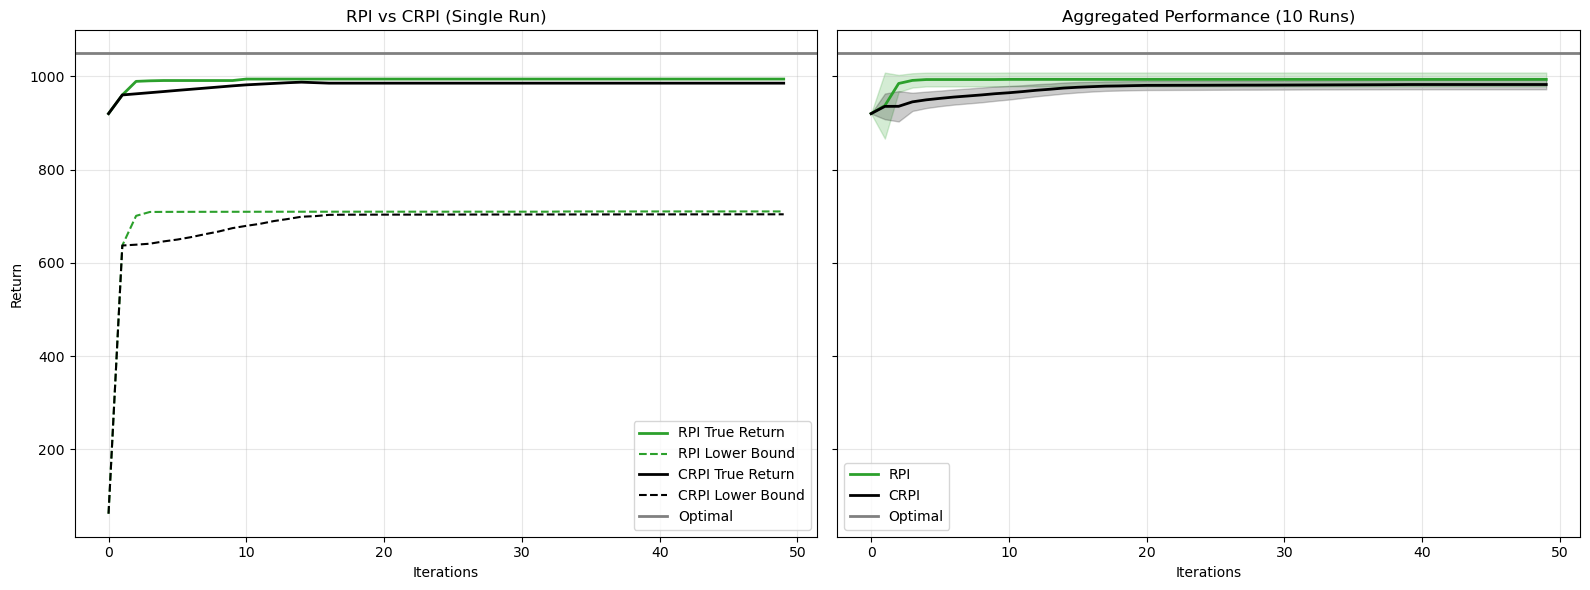

,Algorithm,AUC (mean ± std),Terminal Perf. (mean ± std)
0,RPI,48574.8 ± 728.9,993.48 ± 14.71
1,CRPI,47719.8 ± 489.2,982.48 ± 10.25


In [4]:
# Plotting
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

# Subplot 1: Single Run (RPI vs CRPI overlay)
ax1.plot(rpi_seed0_true, color='#2ca02c', label='RPI True Return', linewidth=2)
ax1.plot(rpi_seed0_est, color='#2ca02c', linestyle='--', label='RPI Lower Bound')
ax1.plot(crpi_seed0_true, color='#000000', label='CRPI True Return', linewidth=2)
ax1.plot(crpi_seed0_est, color='#000000', linestyle='--', label='CRPI Lower Bound')
ax1.axhline(optimal_return, color='gray', linewidth=2, label='Optimal')

ax1.set_title("RPI vs CRPI (Single Run)")
ax1.set_xlabel("Iterations")
ax1.set_ylabel("Return")
ax1.legend()
ax1.grid(alpha=0.3)

# Subplot 2: Aggregated Performance (Mean ± 1 Std Dev)
rpi_mean = np.mean(rpi_all_true, axis=0)
rpi_std = np.std(rpi_all_true, axis=0)
crpi_mean = np.mean(crpi_all_true, axis=0)
crpi_std = np.std(crpi_all_true, axis=0)

ax2.plot(rpi_mean, color='#2ca02c', label='RPI', linewidth=2)
ax2.fill_between(range(iters), rpi_mean - rpi_std, rpi_mean + rpi_std, color='#2ca02c', alpha=0.2)
ax2.plot(crpi_mean, color='#000000', label='CRPI', linewidth=2)
ax2.fill_between(range(iters), crpi_mean - crpi_std, crpi_mean + crpi_std, color='#000000', alpha=0.2)
ax2.axhline(optimal_return, color='gray', linewidth=2, label='Optimal')

ax2.set_title(f"Aggregated Performance ({n_seeds} Runs)")
ax2.set_xlabel("Iterations")
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Metrics Table using trapezoid
rpi_aucs = [np.trapezoid(run) for run in rpi_all_true]
crpi_aucs = [np.trapezoid(run) for run in crpi_all_true]

data = {
    "Algorithm": ["RPI", "CRPI"],
    "AUC (mean ± std)": [f"{np.mean(rpi_aucs):.1f} ± {np.std(rpi_aucs):.1f}",
                         f"{np.mean(crpi_aucs):.1f} ± {np.std(crpi_aucs):.1f}"],
    "Terminal Perf. (mean ± std)": [f"{rpi_mean[-1]:.2f} ± {rpi_std[-1]:.2f}",
                                    f"{crpi_mean[-1]:.2f} ± {crpi_std[-1]:.2f}"]
}
df = pd.DataFrame(data)
display(df)

Running degree 2 polynomial features...


/home/saketh/course-work/6th_sem/.conda/lib/python3.11/site-packages/cvxpy/problems/problem.py:1539: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(


RPI Iteration 1/25 completed.
RPI Iteration 2/25 completed.
RPI Iteration 3/25 completed.
RPI Iteration 4/25 completed.
RPI Iteration 5/25 completed.
RPI Iteration 6/25 completed.
RPI Iteration 7/25 completed.
RPI Iteration 8/25 completed.
RPI Iteration 9/25 completed.
RPI Iteration 10/25 completed.
RPI Iteration 11/25 completed.
RPI Iteration 12/25 completed.
RPI Iteration 13/25 completed.
RPI Iteration 14/25 completed.
RPI Iteration 15/25 completed.
RPI Iteration 16/25 completed.
RPI Iteration 17/25 completed.
RPI Iteration 18/25 completed.
RPI Iteration 19/25 completed.
RPI Iteration 20/25 completed.
RPI Iteration 21/25 completed.
RPI Iteration 22/25 completed.
RPI Iteration 23/25 completed.
RPI Iteration 24/25 completed.
RPI Iteration 25/25 completed.


/home/saketh/course-work/6th_sem/.conda/lib/python3.11/site-packages/cvxpy/problems/problem.py:1539: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(


CRPI Iteration 1/25 | alpha_k = 1.0000
CRPI Iteration 2/25 | alpha_k = 1.0000
CRPI Iteration 3/25 | alpha_k = 1.0000
CRPI Iteration 4/25 | alpha_k = 1.0000
CRPI Iteration 5/25 | alpha_k = 1.0000
CRPI Iteration 6/25 | alpha_k = 1.0000
CRPI Iteration 7/25 | alpha_k = 1.0000
CRPI Iteration 8/25 | alpha_k = 1.0000
CRPI Iteration 9/25 | alpha_k = 1.0000
CRPI Iteration 10/25 | alpha_k = 1.0000
CRPI Iteration 11/25 | alpha_k = 1.0000
CRPI Iteration 12/25 | alpha_k = 1.0000
CRPI Iteration 13/25 | alpha_k = 1.0000
CRPI Iteration 14/25 | alpha_k = 1.0000
CRPI Iteration 15/25 | alpha_k = 1.0000
CRPI Iteration 16/25 | alpha_k = 1.0000
CRPI Iteration 17/25 | alpha_k = 1.0000
CRPI Iteration 18/25 | alpha_k = 1.0000
CRPI Iteration 19/25 | alpha_k = 1.0000
CRPI Iteration 20/25 | alpha_k = 1.0000
CRPI Iteration 21/25 | alpha_k = 1.0000
CRPI Iteration 22/25 | alpha_k = 1.0000
CRPI Iteration 23/25 | alpha_k = 1.0000
CRPI Iteration 24/25 | alpha_k = 1.0000
CRPI Iteration 25/25 | alpha_k = 1.0000
RPI Itera

...

CRPI Iteration 1/25 | alpha_k = 0.5566
CRPI Iteration 2/25 | alpha_k = 0.1477
CRPI Iteration 3/25 | alpha_k = 0.2723
CRPI Iteration 4/25 | alpha_k = 0.6670
CRPI Iteration 5/25 | alpha_k = 0.6225
CRPI Iteration 6/25 | alpha_k = 1.0000
CRPI Iteration 7/25 | alpha_k = 0.1905
CRPI Iteration 8/25 | alpha_k = 0.2799
CRPI Iteration 9/25 | alpha_k = 0.3255
CRPI Iteration 10/25 | alpha_k = 0.4792
CRPI Iteration 11/25 | alpha_k = 0.9203
CRPI Iteration 12/25 | alpha_k = 1.0000
CRPI Iteration 13/25 | alpha_k = 1.0000
CRPI Iteration 14/25 | alpha_k = 1.0000
CRPI Iteration 15/25 | alpha_k = 1.0000
CRPI Iteration 16/25 | alpha_k = 1.0000
CRPI Iteration 17/25 | alpha_k = 1.0000
CRPI Iteration 18/25 | alpha_k = 1.0000
CRPI Iteration 19/25 | alpha_k = 1.0000
CRPI Iteration 20/25 | alpha_k = 1.0000
CRPI Iteration 21/25 | alpha_k = 1.0000
CRPI Iteration 22/25 | alpha_k = 1.0000
CRPI Iteration 23/25 | alpha_k = 1.0000
CRPI Iteration 24/25 | alpha_k = 1.0000
CRPI Iteration 25/25 | alpha_k = 1.0000


/home/saketh/course-work/6th_sem/.conda/lib/python3.11/site-packages/cvxpy/problems/problem.py:1539: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(


RPI Iteration 1/25 completed.
RPI Iteration 2/25 completed.
RPI Iteration 3/25 completed.
RPI Iteration 4/25 completed.
RPI Iteration 5/25 completed.
RPI Iteration 6/25 completed.
RPI Iteration 7/25 completed.
RPI Iteration 8/25 completed.
RPI Iteration 9/25 completed.
RPI Iteration 10/25 completed.
RPI Iteration 11/25 completed.
RPI Iteration 12/25 completed.
RPI Iteration 13/25 completed.
RPI Iteration 14/25 completed.
RPI Iteration 15/25 completed.
RPI Iteration 16/25 completed.
RPI Iteration 17/25 completed.
RPI Iteration 18/25 completed.
RPI Iteration 19/25 completed.
RPI Iteration 20/25 completed.
RPI Iteration 21/25 completed.
RPI Iteration 22/25 completed.
RPI Iteration 23/25 completed.
RPI Iteration 24/25 completed.
RPI Iteration 25/25 completed.


/home/saketh/course-work/6th_sem/.conda/lib/python3.11/site-packages/cvxpy/problems/problem.py:1539: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(


CRPI Iteration 1/25 | alpha_k = 0.5236
CRPI Iteration 2/25 | alpha_k = 0.3075
CRPI Iteration 3/25 | alpha_k = 1.0000
CRPI Iteration 4/25 | alpha_k = 0.5695
CRPI Iteration 5/25 | alpha_k = 0.8594
CRPI Iteration 6/25 | alpha_k = 1.0000
CRPI Iteration 7/25 | alpha_k = 0.5260
CRPI Iteration 8/25 | alpha_k = 0.1989
CRPI Iteration 9/25 | alpha_k = 0.2503
CRPI Iteration 10/25 | alpha_k = 0.4752
CRPI Iteration 11/25 | alpha_k = 0.9075
CRPI Iteration 12/25 | alpha_k = 1.0000
CRPI Iteration 13/25 | alpha_k = 0.3554
CRPI Iteration 14/25 | alpha_k = 0.5499
CRPI Iteration 15/25 | alpha_k = 1.0000
CRPI Iteration 16/25 | alpha_k = 0.4130
CRPI Iteration 17/25 | alpha_k = 0.3817
CRPI Iteration 18/25 | alpha_k = 0.3199
CRPI Iteration 19/25 | alpha_k = 0.3943
CRPI Iteration 20/25 | alpha_k = 0.6462
CRPI Iteration 21/25 | alpha_k = 1.0000
CRPI Iteration 22/25 | alpha_k = 0.5880
CRPI Iteration 23/25 | alpha_k = 0.3114
CRPI Iteration 24/25 | alpha_k = 0.0693
CRPI Iteration 25/25 | alpha_k = 1.0000


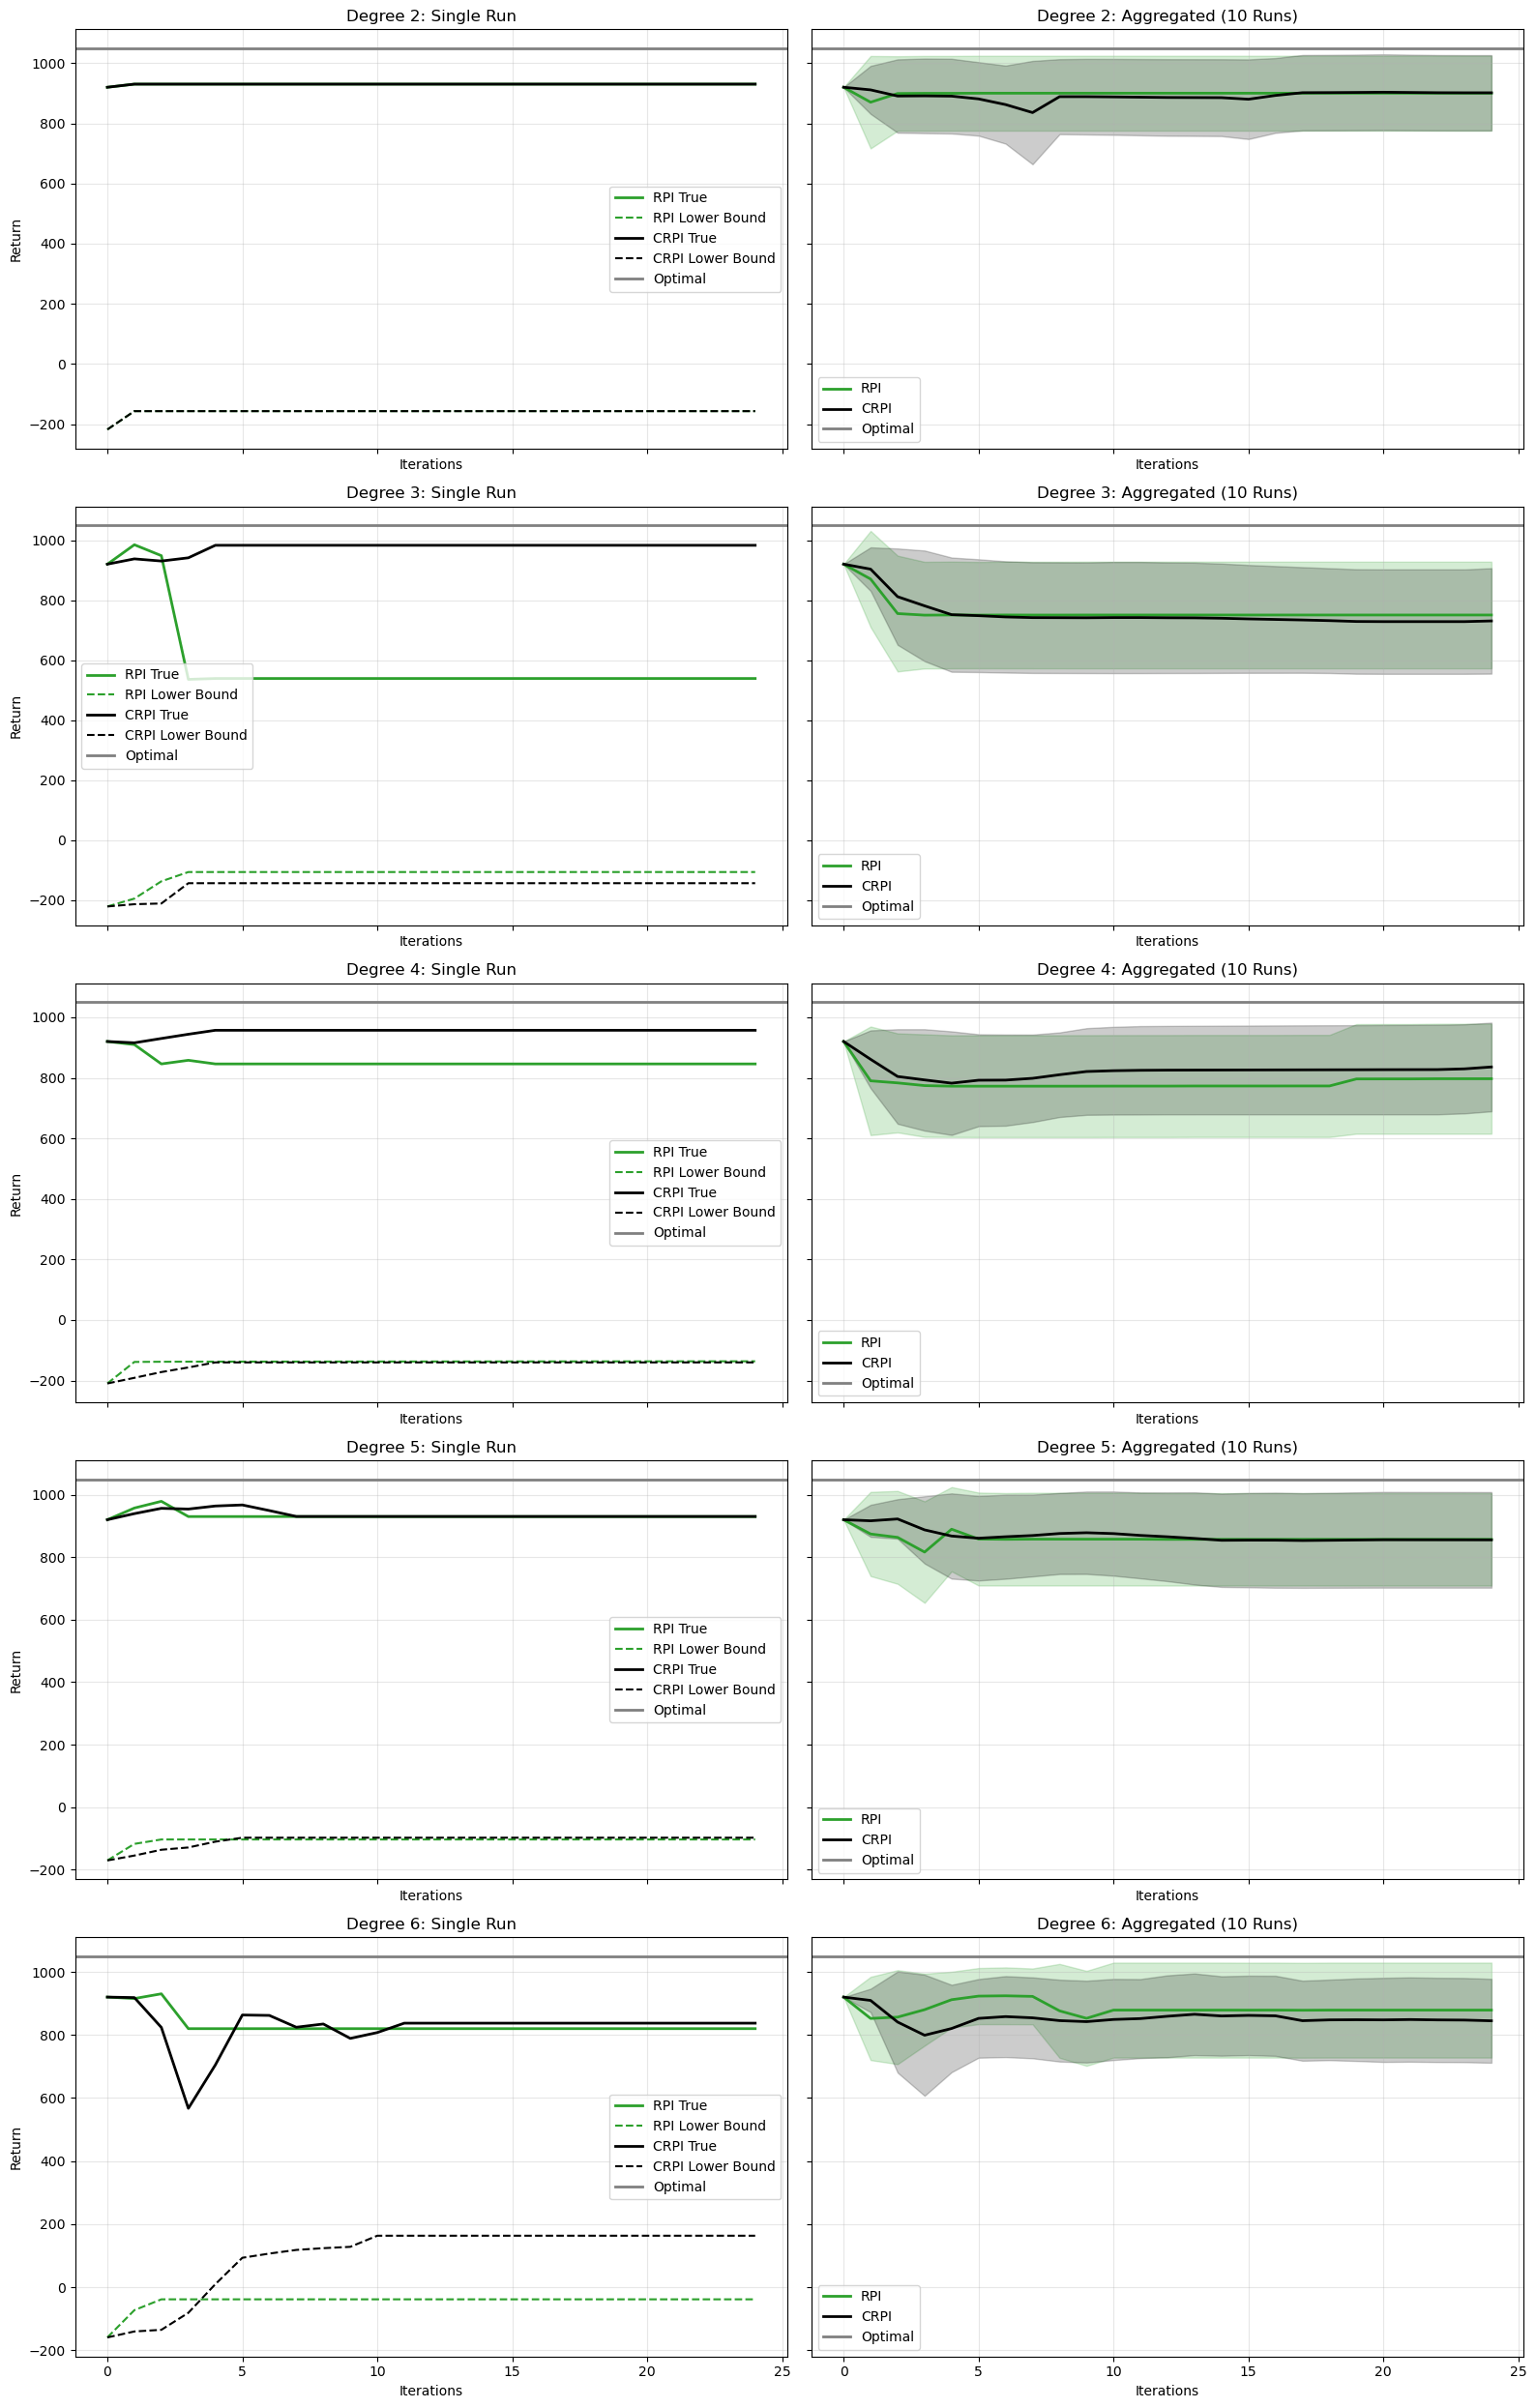

In [8]:
# --- Polynomial Feature Comparison: RPI vs CRPI ---
from function_approximation.polynomial_fa import PolynomialFA

poly_degrees = list(range(2, 7))  # Degrees 2 to 6
iters = 25
n_seeds = 10

# Store results for each degree
results = {}

for deg in poly_degrees:
    rpi_all_true, crpi_all_true = [], []
    rpi_seed0_true, rpi_seed0_est = None, None
    crpi_seed0_true, crpi_seed0_est = None, None
    print(f"Running degree {deg} polynomial features...")
    for seed in range(n_seeds):
        np.random.seed(seed)
        # PolynomialFA will generate features internally
        # Train RPI
        Phi = np.random.uniform(1, 5, size=(SA, 1))
        rpi_agent = RPI(env, PolynomialFA(Phi, deg), gamma, iters)
        _, _, r_hist = rpi_agent.train(track_metrics=True)
        rpi_all_true.append(r_hist['true_return'])
        # Train CRPI

        crpi_agent = CRPI(env, PolynomialFA(Phi, deg), gamma, iters)
        _, _, c_hist = crpi_agent.train(track_metrics=True)
        crpi_all_true.append(c_hist['true_return'])
        if seed == 0:
            rpi_seed0_true = r_hist['true_return']
            rpi_seed0_est = r_hist['est_return']
            crpi_seed0_true = c_hist['true_return']
            crpi_seed0_est = c_hist['est_return']
    results[deg] = {
        'rpi_all_true': np.array(rpi_all_true),
        'crpi_all_true': np.array(crpi_all_true),
        'rpi_seed0_true': rpi_seed0_true,
        'rpi_seed0_est': rpi_seed0_est,
        'crpi_seed0_true': crpi_seed0_true,
        'crpi_seed0_est': crpi_seed0_est
    }

# --- Plotting ---
fig, axes = plt.subplots(len(poly_degrees), 2, figsize=(16, 5 * len(poly_degrees)), sharex=True, sharey='row')
if len(poly_degrees) == 1:
    axes = np.array([axes])  # Ensure axes is 2D

for idx, deg in enumerate(poly_degrees):
    res = results[deg]
    # Single run
    ax1 = axes[idx, 0]
    ax1.plot(res['rpi_seed0_true'], color='#2ca02c', label='RPI True', linewidth=2)
    ax1.plot(res['rpi_seed0_est'], color='#2ca02c', linestyle='--', label='RPI Lower Bound')
    ax1.plot(res['crpi_seed0_true'], color='#000000', label='CRPI True', linewidth=2)
    ax1.plot(res['crpi_seed0_est'], color='#000000', linestyle='--', label='CRPI Lower Bound')
    ax1.axhline(optimal_return, color='gray', linewidth=2, label='Optimal')
    ax1.set_title(f"Degree {deg}: Single Run")
    ax1.set_xlabel("Iterations")
    ax1.set_ylabel("Return")
    ax1.legend()
    ax1.grid(alpha=0.3)
    # Aggregate
    ax2 = axes[idx, 1]
    rpi_mean = np.mean(res['rpi_all_true'], axis=0)
    rpi_std = np.std(res['rpi_all_true'], axis=0)
    crpi_mean = np.mean(res['crpi_all_true'], axis=0)
    crpi_std = np.std(res['crpi_all_true'], axis=0)
    ax2.plot(rpi_mean, color='#2ca02c', label='RPI', linewidth=2)
    ax2.fill_between(range(iters), rpi_mean - rpi_std, rpi_mean + rpi_std, color='#2ca02c', alpha=0.2)
    ax2.plot(crpi_mean, color='#000000', label='CRPI', linewidth=2)
    ax2.fill_between(range(iters), crpi_mean - crpi_std, crpi_mean + crpi_std, color='#000000', alpha=0.2)
    ax2.axhline(optimal_return, color='gray', linewidth=2, label='Optimal')
    ax2.set_title(f"Degree {deg}: Aggregated ({n_seeds} Runs)")
    ax2.set_xlabel("Iterations")
    ax2.legend()
    ax2.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Running 6 detailed runs. This will take a moment...
RPI Iteration 1/25 completed.
RPI Iteration 2/25 completed.
RPI Iteration 3/25 completed.
RPI Iteration 4/25 completed.
RPI Iteration 5/25 completed.
RPI Iteration 6/25 completed.
RPI Iteration 7/25 completed.
RPI Iteration 8/25 completed.
RPI Iteration 9/25 completed.
RPI Iteration 10/25 completed.
RPI Iteration 11/25 completed.
RPI Iteration 12/25 completed.
RPI Iteration 13/25 completed.
RPI Iteration 14/25 completed.
RPI Iteration 15/25 completed.
RPI Iteration 16/25 completed.
RPI Iteration 17/25 completed.
RPI Iteration 18/25 completed.
RPI Iteration 19/25 completed.
RPI Iteration 20/25 completed.
RPI Iteration 21/25 completed.
RPI Iteration 22/25 completed.
RPI Iteration 23/25 completed.
RPI Iteration 24/25 completed.
RPI Iteration 25/25 completed.
CRPI Iteration 1/25 | alpha_k = 1.0000
CRPI Iteration 2/25 | alpha_k = 0.0845
CRPI Iteration 3/25 | alpha_k = 0.0918
CRPI Iteration 4/25 | alpha_k = 0.1012
CRPI Iteration 5/25 | alph

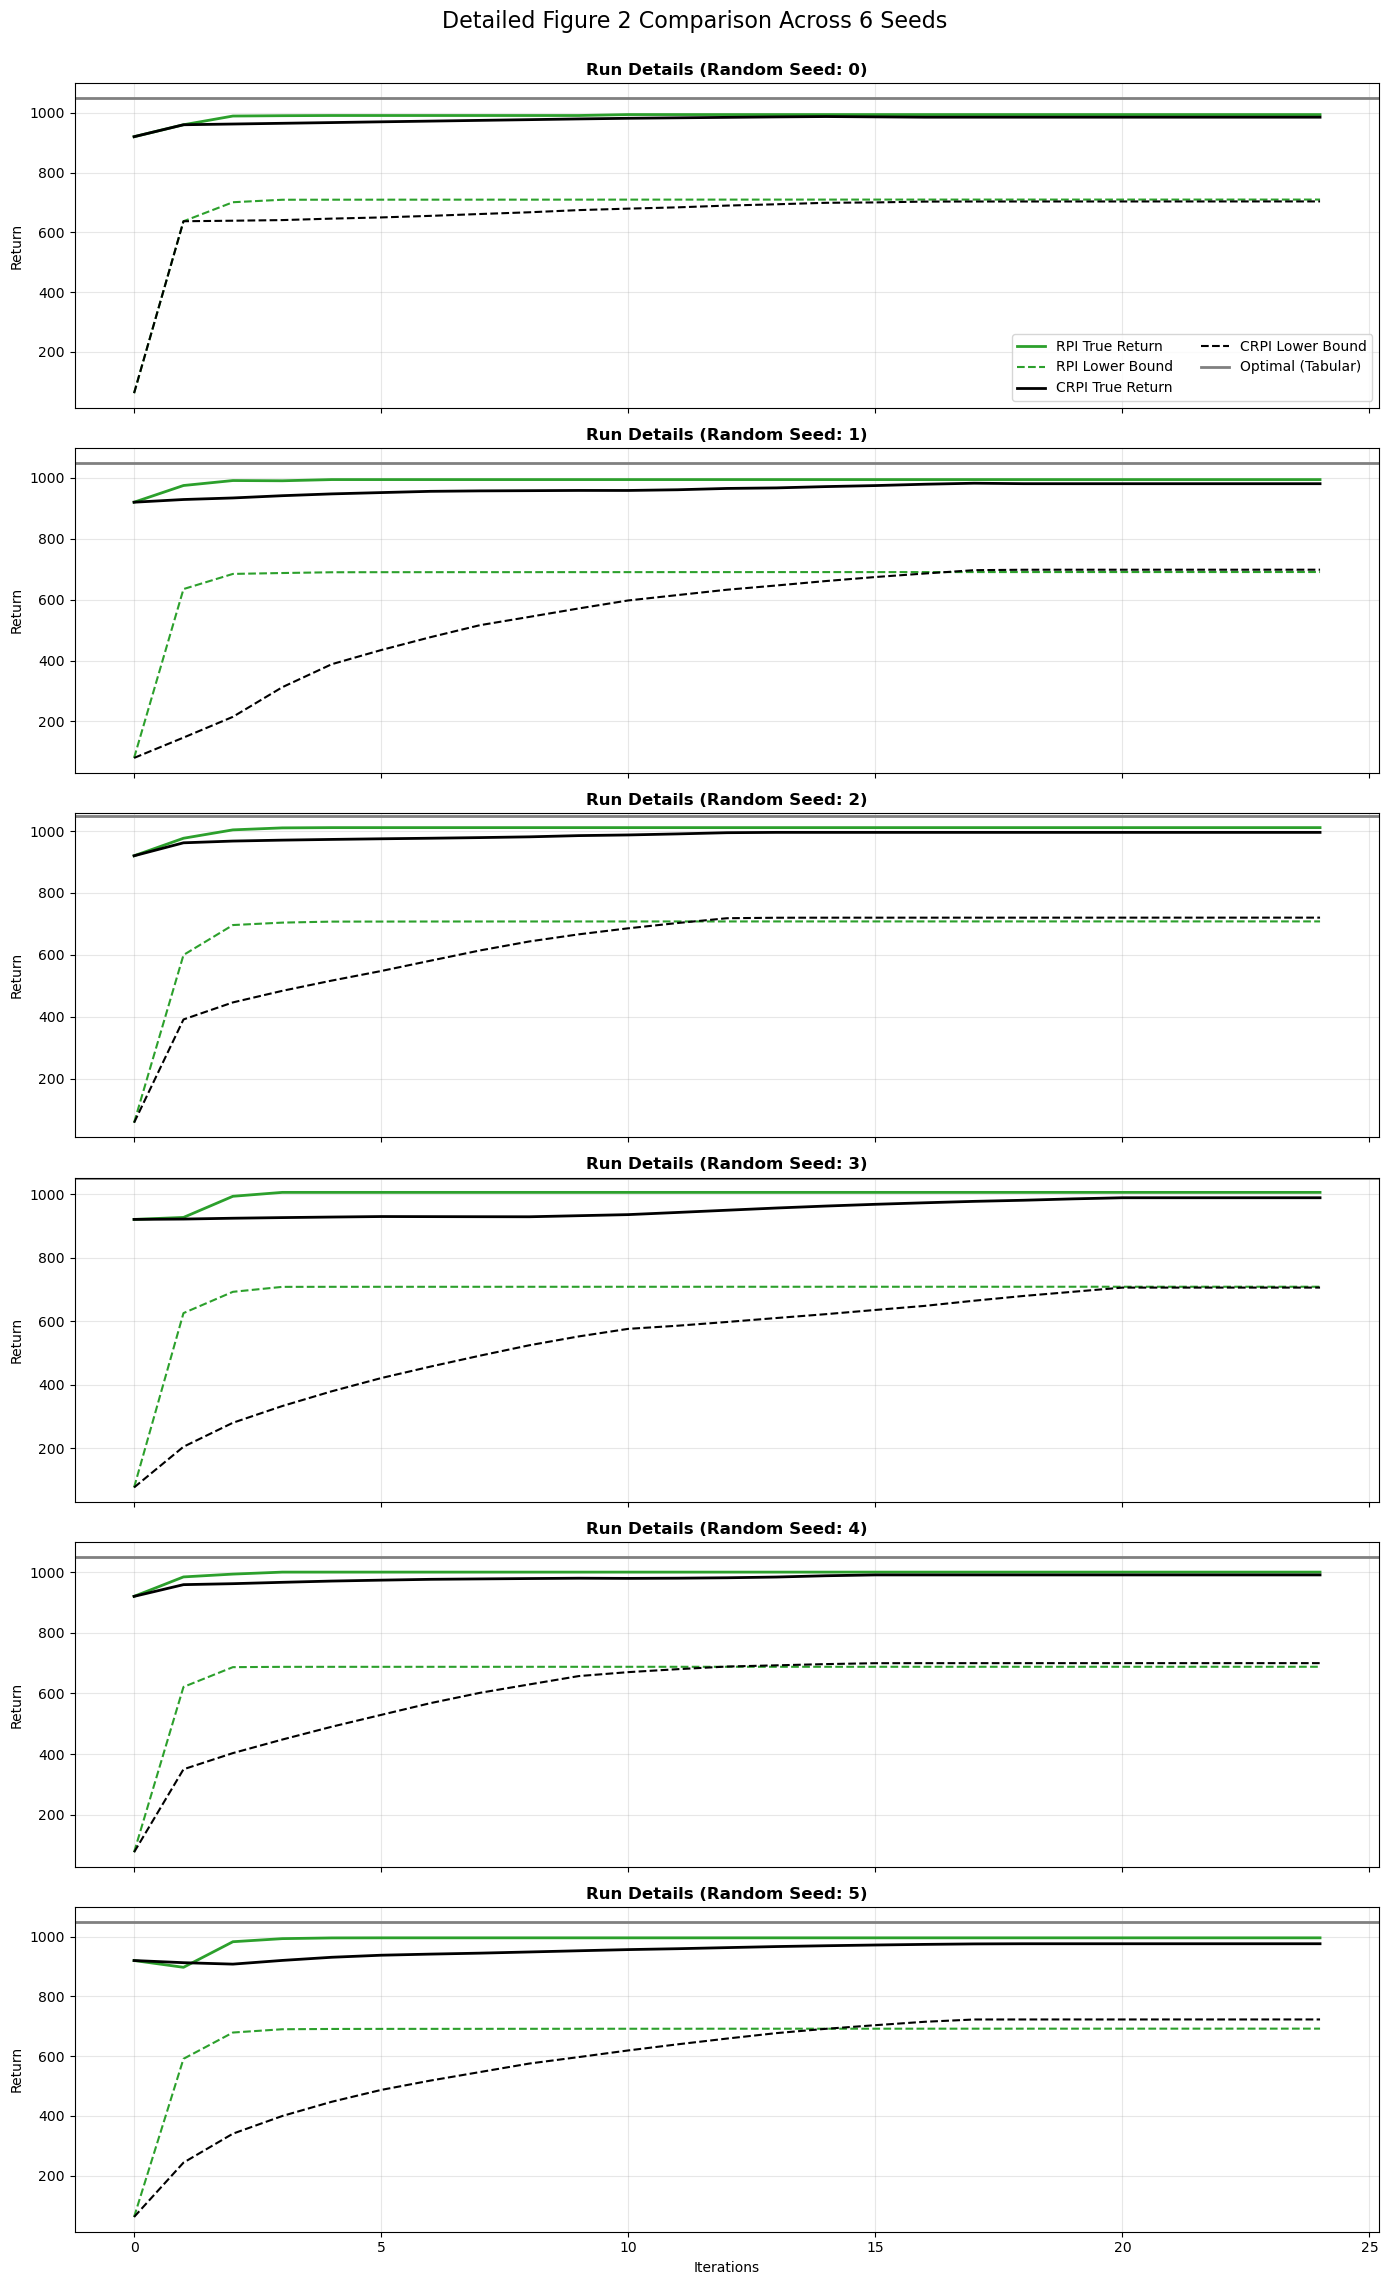

------------------------------
Average Terminal Performance across 6 Runs:
RPI: 1000.155
CRPI: 986.216


In [9]:
# --- CELL 3 ---
n_seeds = 6
# Store metrics for output
rpi_terminals = []
crpi_terminals = []

# Create a 5x1 grid of stacked subplots
fig, axes = plt.subplots(n_seeds, 1, figsize=(14, 4 * n_seeds), sharex=True)
fig.suptitle(f"Detailed Figure 2 Comparison Across {n_seeds} Seeds", fontsize=16)

print(f"Running {n_seeds} detailed runs. This will take a moment...")

# Loop through each seed to train and plot immediately
for i in range(n_seeds):
    seed = i  # Keep seed consistent with index
    ax = axes[i]  # Get the current subplot

    # -- Fixed-Seed Feature Generation --
    np.random.seed(seed)
    Phi = np.random.uniform(1, 5, size=(SA, d_features))
    Phi[:, 0] = 1.0  # Bias column fix

    # -- 1. Train RPI --
    rpi_agent = RPI(env, LinearFA(Phi), gamma, iters)
    # Refactored train call, extracting history
    _, _, rpi_hist = rpi_agent.train(track_metrics=True)
    rpi_terminals.append(rpi_hist['true_return'][-1])

    # -- 2. Train CRPI --
    crpi_agent = CRPI(env, LinearFA(Phi), gamma, iters)
    # Refactored train call, extracting history
    _, _, crpi_hist = crpi_agent.train(track_metrics=True)
    crpi_terminals.append(crpi_hist['true_return'][-1])

    # -- 3. Plotting Subplot (Strict Figure 2 Template) --
    # Plot RPI (Solid True, Dotted Estimated)
    ax.plot(rpi_hist['true_return'], color='#2ca02c', label='RPI True Return', linewidth=2)
    ax.plot(rpi_hist['est_return'], color='#2ca02c', linestyle='--', label='RPI Lower Bound')

    # Plot CRPI (Solid True, Dotted Estimated)
    ax.plot(crpi_hist['true_return'], color='#000000', label='CRPI True Return', linewidth=2)
    ax.plot(crpi_hist['est_return'], color='#000000', linestyle='--', label='CRPI Lower Bound')

    # Plot Optimal Baseline
    ax.axhline(optimal_return, color='gray', linewidth=2, linestyle='-', label='Optimal (Tabular)')

    # Labels and formatting for each subplot
    ax.set_title(f"Run Details (Random Seed: {seed})", fontweight='bold')
    ax.set_ylabel("Return")
    ax.grid(alpha=0.3)

    # Add legend only to the first subplot to reduce clutter
    if i == 0:
        ax.legend(loc='lower right', ncol=2)

# Set common x-label
axes[-1].set_xlabel("Iterations")

plt.tight_layout(rect=[0, 0.03, 1, 0.98]) # Adjust layout to fit main title
plt.show()

# -- 4. Output Summary Metrics --
print("-" * 30)
print(f"Average Terminal Performance across {n_seeds} Runs:")
print(f"RPI: {np.mean(rpi_terminals):.3f}")
print(f"CRPI: {np.mean(crpi_terminals):.3f}")